# Tratamiento de Outliers
En este notebook se detectan y tratan los valores atípicos de la columna `monto_compra` del dataset depurado de la Semana 6, usando los métodos IQR y z-score, y luego se suaviza la serie de ventas diarias con una media móvil.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("S06_PD_Camacho_Serpa_DatasetDepurado.xls")

## Cálculo del IQR

In [3]:
Q1 = df["monto_compra"].quantile(0.25)
Q3 = df["monto_compra"].quantile(0.75)
IQR = Q3 - Q1
print("Q1:", Q1, "Q3:", Q3, "Rango intercuartilico:", IQR)

Q1: 222700.0 Q3: 857400.0 Rango intercuartilico: 634700.0


In [4]:
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)

Limite inferior: -729350.0
Limite superior: 1809450.0


## Límites IQR de monto_compra
Los cuartiles nos dieron **Q1 = 222.700** y **Q3 = 857.400**, con un IQR de **634.700**.

Aplicando la regla de 1,5 × IQR, los límites quedan:

- **Límite inferior: -729.350**
- **Límite superior: 1.809.450**

El límite inferior sale negativo, pero como `monto_compra` no puede ser menor que 0, en la práctica lo tratamos como 0. Esto es normal en columnas sesgadas hacia valores altos, como suelen serlo las ventas.

In [5]:
outliers_iqr = df[(df["monto_compra"] < limite_inferior) | (df["monto_compra"] > limite_superior)]

In [6]:
print(f"Valores atípicos según IQR: {len(outliers_iqr)}")

Valores atípicos según IQR: 64816


## Outliers detectados con IQR
El método IQR marcó **64.816 registros** como atípicos, lo que corresponde a un **10,45 %** del dataset. Es un número alto, pero tiene sentido: `monto_compra` es una variable muy sesgada — la mayoría de compras son pequeñas y unas pocas son extremadamente grandes, que arrastran la distribución hacia la derecha. En este tipo de columnas el IQR tiende a marcar bastantes valores como atípicos, y no todos son necesariamente errores.

In [7]:
media = df["monto_compra"].mean()
desviacion = df["monto_compra"].std()

In [8]:
df["z_monto_compra"] = (df["monto_compra"] - media) / desviacion

In [9]:
outliers_zscore = df[df["z_monto_compra"].abs() > 3]
print(f"Valores atípicos según z-score: {len(outliers_zscore)}")

Valores atípicos según z-score: 123


## Comparación IQR vs. z-score
Los dos métodos dieron números muy diferentes:

- **IQR:** 64.816 atípicos (10,45 %)
- **z-score:** solo 123 atípicos (0,02 %)

La razón es que en `monto_compra` hay unos pocos valores extremadamente altos (algunos incluso llegan a miles de millones), y esos valores **inflan muchísimo la media y la desviación estándar**. Al calcular el z-score con una desviación tan enorme, casi ningún valor supera el umbral de |z| > 3, así que el método "esconde" a los atípicos moderados.

En variables muy sesgadas como esta, el **IQR es más confiable** porque se basa en la mediana y los cuartiles, que no se ven arrastrados por los extremos.

<Axes: >

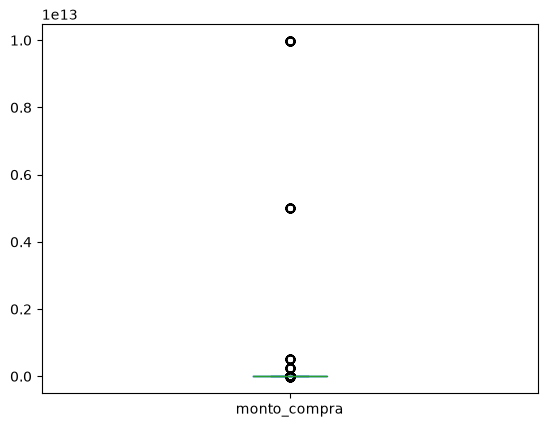

In [10]:
df["monto_compra"].plot(kind="box")

<Axes: xlabel='unidades_vendidas', ylabel='monto_compra'>

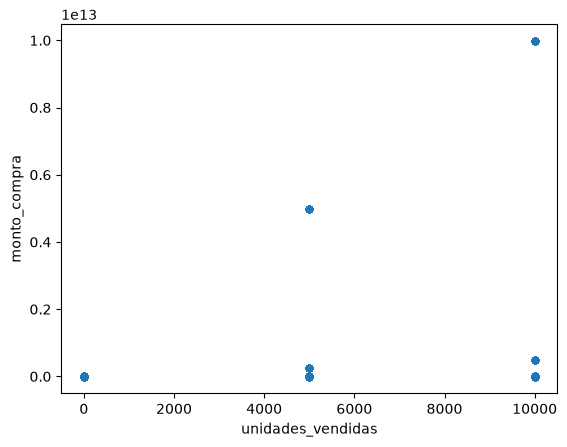

In [11]:
df.plot(kind="scatter", x="unidades_vendidas", y="monto_compra")

## Confirmación visual
- **Boxplot:** se ven muchos puntos por encima del bigote superior, lo que confirma visualmente que el IQR detectó una cantidad grande de atípicos. La caja se ve muy comprimida cerca del cero porque los valores extremos hacen que la escala del eje sea enorme.
- **Scatter (unidades_vendidas vs. monto_compra):** la nube principal está agrupada en la esquina inferior izquierda, pero hay puntos sueltos muy alejados hacia arriba. Esos son buenos candidatos a atípicos multivariados: no solo tienen un monto alto, sino que además no acompañan a un aumento proporcional de unidades vendidas.

Los dos gráficos coinciden con la idea de que hay outliers reales, y que probablemente sean errores o casos muy particulares.

In [12]:
outliers_iqr[["monto_compra", "canal_compra", "unidades_vendidas"]]

,monto_compra,canal_compra,unidades_vendidas
2,-1.792800e+06,Tienda,-3
6,2.234700e+06,Web,3
28,-1.204800e+06,Web,3
30,1.831500e+06,Web,3
39,5.720000e+08,Tienda,5000
...,...,...,...
619935,2.463600e+06,Web,3
619936,-1.302600e+06,Marketplace,-3
619956,-1.772100e+06,Tienda,3
619958,3.505000e+06,Marketplace,5


## Decisión por cada grupo de atípicos
Al revisar el detalle de los outliers, encontramos dos grupos muy distintos:

**Grupo 1 — Errores de captura evidentes.** Los montos que llegan a miles de millones o incluso billones (por ejemplo, valores del orden de 10⁹ o superiores) claramente no corresponden a compras reales de retail. Son errores de digitación con ceros de más. **Decisión: Winsorizar al límite superior.**

**Grupo 2 — Compras grandes pero plausibles.** Los montos entre el límite superior (1.809.450) y unos pocos millones sí pueden ser compras reales, especialmente si están asociadas a muchas unidades vendidas. **Decisión: marcarlos con una columna indicadora `es_venta_corporativa` para poder analizarlos aparte, pero también aplicarles el clip para que no distorsionen la media.**

Como criterio conservador, aplicamos el clip a todos los valores por encima del límite superior. Los que consideramos legítimos quedan marcados con la columna indicadora, así no se pierde la información de que eran ventas de monto grande.

In [13]:
df["es_venta_corporativa"] = df["monto_compra"] > limite_superior
df["es_venta_corporativa"].sum()

np.int64(53224)

In [14]:
df["monto_compra"] = df["monto_compra"].clip(upper=limite_superior, lower=limite_inferior)

In [15]:
print("Media después del tratamiento:", df["monto_compra"].mean())
print("Desviación estándar después del tratamiento:", df["monto_compra"].std())
print("Máximo después del tratamiento:", df["monto_compra"].max())

Media después del tratamiento: 596836.6742904842
Desviación estándar después del tratamiento: 584376.2185389813
Máximo después del tratamiento: 1809450.0


## Efecto del tratamiento

- **Media antes:** ~1.277.359.810 (jalada por los valores extremos hacia arriba)
- **Media después:** ~596.837

- **Desviación estándar antes:** ~99.646.796.132 (absurdamente alta)
- **Desviación estándar después:** ~584.376

- **Máximo después:** 1.809.450 (exactamente el límite superior, como esperábamos)

Antes, unos pocos valores extremos estaban distorsionando por completo las estadísticas. Ahora los indicadores reflejan el comportamiento real de la mayoría de las compras. Las filas con montos originalmente muy altos quedaron marcadas en `es_venta_corporativa`, así que si más adelante queremos analizarlas por separado, no perdemos esa información.

## Suavizado de la serie diaria

In [16]:
df["fecha_pedido"] = pd.to_datetime(df["fecha_pedido"], errors="coerce")
ventas_diarias = df.groupby("fecha_pedido")["monto_compra"].sum().reset_index()

In [17]:
ventas_diarias["suavizado"] = ventas_diarias["monto_compra"].rolling(window=7).mean()

<Axes: xlabel='fecha_pedido'>

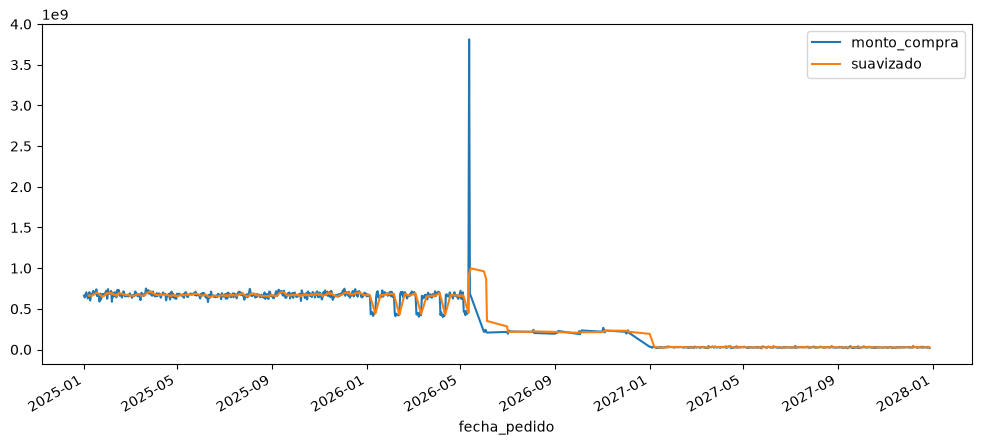

In [18]:
ventas_diarias.plot(x="fecha_pedido", y=["monto_compra", "suavizado"], figsize=(12,5))

## Suavizado de ventas diarias
Al agrupar las ventas por día y comparar la serie original con la media móvil de 7 días, la línea suavizada se ve mucho más estable: se pierden los picos y valles del día a día (ruido), y se puede ver una **tendencia general** que antes quedaba oculta. Es una forma sencilla de identificar patrones semanales o estacionales sin que las variaciones diarias distraigan.

In [19]:
df.to_csv("S07_PD_Camacho_Serpa_DatasetSinOutliers.csv", index=False)